# Step 6 JAM aperture velocity dispersion

This notebook reads the Step 6 imaging-only posterior, randomly selects 1000 posterior samples, converts the stellar-light MGE plus gNFW halo MGE into the input convention used by `jampy`, computes the luminosity-weighted central aperture velocity dispersion within 0.5 arcsec, and makes a corner plot.

Convention check: `jampy` expects `surf_lum` to be the peak surface value of each tracer MGE Gaussian and `surf_pot` to be the peak total-mass surface density in `Msun / pc^2`. The Herculens/lenstronomy Gaussian `amp` is an integrated 2D amplitude, so the corresponding peak value is `amp / (2 pi sigma_product^2)`. Because Herculens uses the product-average ellipticity convention, the JAM major-axis dispersion is `sigma_jam = sigma_product / sqrt(qobs)`, and the peak value remains `amp / (2 pi sigma_product^2)`.

The M/L-gradient stellar mass amplitudes are recomputed exactly as in the Step 6 script: `mass_from_light_amp = light_amp / sum(light_amp) * m2l_ratio * sigma**m2l_ratio_slope`.

Note: the calculation below uses the axisymmetric JAM approximation. It recenters the dynamical model on the flux-weighted stellar MGE centroid and treats all MGE components as coaxial. The posterior halo center offset and external perturbers/shear/convergence are lensing ingredients and are not included as local stellar-dynamical mass components here.


## References for conventions

JAMPY `jam.axi.proj` expects `surf_lum` to be the peak MGE surface brightness and `surf_pot` to be the peak total-mass surface density. Herculens/lenstronomy Gaussian `amp` is the integrated two-dimensional amplitude. The Step 6 M/L gradient formula is copied from `Step_6_stardm_model_imaging_only_to_hmc.py`.


In [1]:
# ============================================================
# Imports
# ============================================================
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

from pathlib import Path

import arviz as az
import corner
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from astropy import constants as const
from astropy import units as u
from astropy.cosmology import FlatLambdaCDM
from tqdm.auto import tqdm

import jampy as jam

from jax_lensing_profiles.MassModel.Profiles.CuspyNFW_ellipse_kappa import CuspyNFW_3D_fn
from jax_lensing_profiles.MassModel.Profiles.MGE import MGE

jax.config.update("jax_enable_x64", True)


In [2]:
# ============================================================
# Configuration
# ============================================================
NC_PATH = '/mnt/lustre/tianli/quasar_hmc/WFI2033_inferh0_step6_imaging_only_infer_LCDM_20260502_08/WFI2033_all_inferh0_step6_imaging_only_infer_LCDM.nc'
FIXED_FIVE_GAUSS_PATH = './result/result_ss=2_fullconcen_light_multimass_20260427_14/fixed_five_gaussians_corrected_psf_ss=2_fullconcen_light_multimass.npz'

Z_LENS = 0.6575
Z_SOURCE = 1.662
N_RANDOM_SAMPLES = 10000
RNG_SEED = 2033
APER_RADIUS_ARCSEC = 0.5
APER_GRID_SIDE = 41
INC_DEG = 90.0
BETA_CONSTANT = 2.0
MBH_MSUN = 0.0

CORNER_OUT = './Paper/jampy_sigma_ap_corner.pdf'
SAMPLES_OUT = './Paper/jampy_sigma_ap_samples.csv'

POST_VARS = [
    'm2l_ratio', 'm2l_ratio_slope',
    'kappa_s_halo', 'gammain_halo', 'Rs_halo', 'e_halo', 'center_halo',
    'omega_m_cosmo', 'H0_cosmo',
]

print('NC_PATH =', NC_PATH)
print('FIXED_FIVE_GAUSS_PATH =', FIXED_FIVE_GAUSS_PATH)


NC_PATH = /mnt/lustre/tianli/quasar_hmc/WFI2033_inferh0_step6_imaging_only_infer_LCDM_20260502_08/WFI2033_all_inferh0_step6_imaging_only_infer_LCDM.nc
FIXED_FIVE_GAUSS_PATH = ./result/result_ss=2_fullconcen_light_multimass_20260427_14/fixed_five_gaussians_corrected_psf_ss=2_fullconcen_light_multimass.npz


In [3]:
# ============================================================
# Load the fixed five-Gaussian stellar light MGE
# ============================================================
fixed = np.load(FIXED_FIVE_GAUSS_PATH)
light_amp = fixed['amp'].astype(float)
sigma_prod = fixed['sigma'].astype(float)
e1_light = fixed['e1'].astype(float)
e2_light = fixed['e2'].astype(float)
center_x = fixed['center_x'].astype(float)
center_y = fixed['center_y'].astype(float)

print('fixed MGE keys:', fixed.files)
for key in fixed.files:
    print(f'{key:8s}', fixed[key])

light_centroid = np.array([np.sum(light_amp * center_x) / np.sum(light_amp), np.sum(light_amp * center_y) / np.sum(light_amp)])
print('flux-weighted stellar MGE centroid [arcsec] =', light_centroid)


fixed MGE keys: ['amp', 'sigma', 'e1', 'e2', 'center_x', 'center_y']
amp      [ 126.87107673  107.75939469  214.76170615  618.59013138 2013.69845619]
sigma    [0.01904452 0.04217237 0.09683986 0.24231872 0.85271635]
e1       [-0.14037145 -0.0578769  -0.08466947 -0.04794419 -0.05653835]
e2       [-0.01248935  0.06503772  0.11774388  0.11001114  0.1275457 ]
center_x [-0.002724    0.00140216  0.00030878  0.00230782  0.00230782]
center_y [-0.01424388 -0.00944529 -0.01407877 -0.01382772 -0.01382772]
flux-weighted stellar MGE centroid [arcsec] = [ 0.00192968 -0.0137091 ]


In [4]:
# ============================================================
# Geometry and unit helpers
# ============================================================
def ellipticity_to_q_phi(e1, e2):
    ellip = np.minimum(np.sqrt(np.asarray(e1, dtype=float)**2 + np.asarray(e2, dtype=float)**2), 0.9999)
    q = (1.0 - ellip) / (1.0 + ellip)
    phi = 0.5 * np.arctan2(e2, e1)
    return q, phi


def sigma_crit_and_scale(H0, Om0, z_lens=Z_LENS, z_source=Z_SOURCE):
    cosmo = FlatLambdaCDM(H0=float(H0) * u.km / u.s / u.Mpc, Om0=float(Om0))
    D_d = cosmo.angular_diameter_distance(z_lens)
    D_s = cosmo.angular_diameter_distance(z_source)
    D_ds = cosmo.angular_diameter_distance_z1z2(z_lens, z_source)
    sigma_crit = (const.c**2 / (4.0 * np.pi * const.G) * D_s / (D_d * D_ds)).to(u.Msun / u.pc**2)
    pc_per_arcsec = (D_d.to(u.pc) * (1.0 * u.arcsec).to(u.rad).value).value
    return sigma_crit.value, pc_per_arcsec, D_d.to(u.Mpc).value


def herculens_integrated_amp_to_jam_peak(amp_integrated, sigma_product):
    return np.asarray(amp_integrated, dtype=float) / (2.0 * np.pi * np.asarray(sigma_product, dtype=float)**2)


def herculens_sigma_product_to_jam_major_sigma(sigma_product, qobs):
    return np.asarray(sigma_product, dtype=float) / np.sqrt(np.asarray(qobs, dtype=float))


def projected_mge_surface(x, y, surf_peak, sigma_major, qobs):
    x = np.asarray(x)[:, None]
    y = np.asarray(y)[:, None]
    surf_peak = np.asarray(surf_peak, dtype=float)[None, :]
    sigma_major = np.asarray(sigma_major, dtype=float)[None, :]
    qobs = np.asarray(qobs, dtype=float)[None, :]
    expo = -0.5 * ((x / sigma_major)**2 + (y / (sigma_major * qobs))**2)
    return np.sum(surf_peak * np.exp(expo), axis=1)


def aperture_grid(radius_arcsec=APER_RADIUS_ARCSEC, side=APER_GRID_SIDE):
    grid = np.linspace(-radius_arcsec, radius_arcsec, side)
    xx, yy = np.meshgrid(grid, grid, indexing='xy')
    mask = xx**2 + yy**2 <= radius_arcsec**2
    mask &= (xx != 0.0) | (yy != 0.0)
    return xx[mask].ravel(), yy[mask].ravel()

x_ap, y_ap = aperture_grid()
print('aperture grid points:', x_ap.size)


aperture grid points: 1252


In [5]:
# ============================================================
# gNFW MGE decomposition with the same numerical setup as Step 6
# ============================================================
class CuspyNFWEllipseKappaForJAM(MGE):
    def __init__(self):
        super().__init__(CuspyNFW_3D_fn, 'R_s', n_gauss=20, n_terms=28, sigma_start_mult=1/200, sigma_end_mult=20, three_d=True)

halo_mge = CuspyNFWEllipseKappaForJAM()

def halo_mge_peak_kappa_and_sigma(Rs_halo, kappa_s_halo, gammain_halo):
    amps_peak_kappa, sigmas_product = halo_mge.decompose(R_s=float(Rs_halo), kappa_s=float(kappa_s_halo), gamma=float(gammain_halo))
    return np.asarray(amps_peak_kappa, dtype=float), np.asarray(sigmas_product, dtype=float)


In [6]:
# ============================================================
# Read only the scalar/vector parameters needed for JAM
# ============================================================
post = xr.open_dataset(NC_PATH, group='posterior', engine='h5netcdf')[POST_VARS].load()
print(post)

stacked = post.stack(sample=('chain', 'draw'))
n_total = int(stacked.sizes['sample'])
rng = np.random.default_rng(RNG_SEED)
sample_indices = rng.choice(n_total, size=N_RANDOM_SAMPLES, replace=False)
sampled = stacked.isel(sample=sample_indices)

print('total posterior samples =', n_total)
print('random samples used =', sampled.sizes['sample'])


<xarray.Dataset> Size: 6MB
Dimensions:                  (chain: 8, draw: 8000, Lens mass vectors - [2]: 2,
                              center_halo_dim_0: 2)
Coordinates:
  * chain                    (chain) int64 64B 0 1 2 3 4 5 6 7
  * draw                     (draw) int64 64kB 0 1 2 3 4 ... 7996 7997 7998 7999
  * Lens mass vectors - [2]  (Lens mass vectors - [2]) int64 16B 0 1
  * center_halo_dim_0        (center_halo_dim_0) int64 16B 0 1
Data variables:
    m2l_ratio                (chain, draw) float64 512kB 3.447 3.409 ... 3.453
    m2l_ratio_slope          (chain, draw) float64 512kB 0.219 0.2139 ... 0.2685
    kappa_s_halo             (chain, draw) float64 512kB 0.1018 ... 0.0465
    gammain_halo             (chain, draw) float64 512kB 1.236 1.199 ... 1.459
    Rs_halo                  (chain, draw) float64 512kB 3.307 2.93 ... 5.17
    e_halo                   (chain, draw, Lens mass vectors - [2]) float64 1MB ...
    center_halo              (chain, draw, center_halo_dim_0)

In [7]:
# ============================================================
# Extract helpers
# ============================================================
def scalar_sample(ds, name, i):
    return float(np.ravel(ds[name].isel(sample=i).values)[0])

def vec2_sample(ds, name, i):
    return np.ravel(ds[name].isel(sample=i).values).astype(float)[:2]


In [8]:
# ============================================================
# One-sample JAM calculation
# ============================================================
q_lum, phi_lum = ellipticity_to_q_phi(e1_light, e2_light)
sigma_lum_major = herculens_sigma_product_to_jam_major_sigma(sigma_prod, q_lum)

def run_jam_for_sample(ds, i):
    H0 = scalar_sample(ds, 'H0_cosmo', i)
    Om0 = scalar_sample(ds, 'omega_m_cosmo', i)
    m2l_ratio = scalar_sample(ds, 'm2l_ratio', i)
    m2l_slope = scalar_sample(ds, 'm2l_ratio_slope', i)
    kappa_s = scalar_sample(ds, 'kappa_s_halo', i)
    gamma_in = scalar_sample(ds, 'gammain_halo', i)
    Rs = scalar_sample(ds, 'Rs_halo', i)
    e_halo = vec2_sample(ds, 'e_halo', i)

    sigma_crit_msun_pc2, pc_per_arcsec, Dd_mpc = sigma_crit_and_scale(H0, Om0)

    surf_lum = herculens_integrated_amp_to_jam_peak(light_amp, sigma_prod) / pc_per_arcsec**2

    ml_gauss = m2l_ratio * sigma_prod**m2l_slope
    star_amp_kappa_arcsec2 = light_amp / np.sum(light_amp) * ml_gauss
    star_peak_kappa = herculens_integrated_amp_to_jam_peak(star_amp_kappa_arcsec2, sigma_prod)
    star_surf_pot = star_peak_kappa * sigma_crit_msun_pc2
    star_sigma_major = sigma_lum_major
    star_qobs = q_lum

    halo_peak_kappa, halo_sigma_prod = halo_mge_peak_kappa_and_sigma(Rs, kappa_s, gamma_in)
    q_halo = np.repeat(ellipticity_to_q_phi(e_halo[0], e_halo[1])[0], halo_peak_kappa.size)
    halo_sigma_major = herculens_sigma_product_to_jam_major_sigma(halo_sigma_prod, q_halo)
    halo_surf_pot = halo_peak_kappa * sigma_crit_msun_pc2

    surf_pot = np.concatenate([star_surf_pot, halo_surf_pot])
    sigma_pot = np.concatenate([star_sigma_major, halo_sigma_major])
    qobs_pot = np.concatenate([star_qobs, q_halo])

    beta = np.full_like(sigma_lum_major, BETA_CONSTANT, dtype=float)
    out = jam.axi.proj(
        surf_lum, sigma_lum_major, q_lum,
        surf_pot, sigma_pot, qobs_pot,
        INC_DEG, MBH_MSUN, Dd_mpc, x_ap, y_ap,
        beta=beta, moment='zz', align='cyl', ml=1.0,
        sigmapsf=0.5, pixsize=0.05, plot=False, quiet=True,
    )

    vrms = np.asarray(out.model, dtype=float)
    light_weights = projected_mge_surface(x_ap, y_ap, surf_lum, sigma_lum_major, q_lum)
    sigma_ap = np.sqrt(np.sum(light_weights * vrms**2) / np.sum(light_weights))

    total_stellar_mass = np.sum(star_amp_kappa_arcsec2) * sigma_crit_msun_pc2 * pc_per_arcsec**2
    total_halo_mass_mge = np.sum(halo_surf_pot * 2.0 * np.pi * halo_sigma_major**2 * q_halo * pc_per_arcsec**2)

    return {
        'sample_index': int(sample_indices[i]),
        'chain': int(sampled['chain'].isel(sample=i).values),
        'draw': int(sampled['draw'].isel(sample=i).values),
        'sigma_ap_0p5_arcsec_km_s': float(sigma_ap),
        'm2l_ratio': float(m2l_ratio),
        'm2l_ratio_slope': float(m2l_slope),
        'total_stellar_mass_Msun': float(total_stellar_mass),
        'log10_total_stellar_mass': float(np.log10(total_stellar_mass)),
        'halo_mge_mass_Msun': float(total_halo_mass_mge),
        'kappa_s_halo': float(kappa_s),
        'gammain_halo': float(gamma_in),
        'Rs_halo': float(Rs),
        'H0_cosmo': float(H0),
        'omega_m_cosmo': float(Om0),
    }


In [9]:
# ============================================================
# Run JAM for the random posterior samples
# ============================================================
rows = []
for i in tqdm(range(N_RANDOM_SAMPLES), desc='JAM aperture dispersion'):
    rows.append(run_jam_for_sample(sampled, i))

jam_df = pd.DataFrame(rows)

JAM aperture dispersion:   0%|          | 0/10000 [00:00<?, ?it/s]

saved corner plot to ./Paper/jampy_sigma_ap_corner.pdf


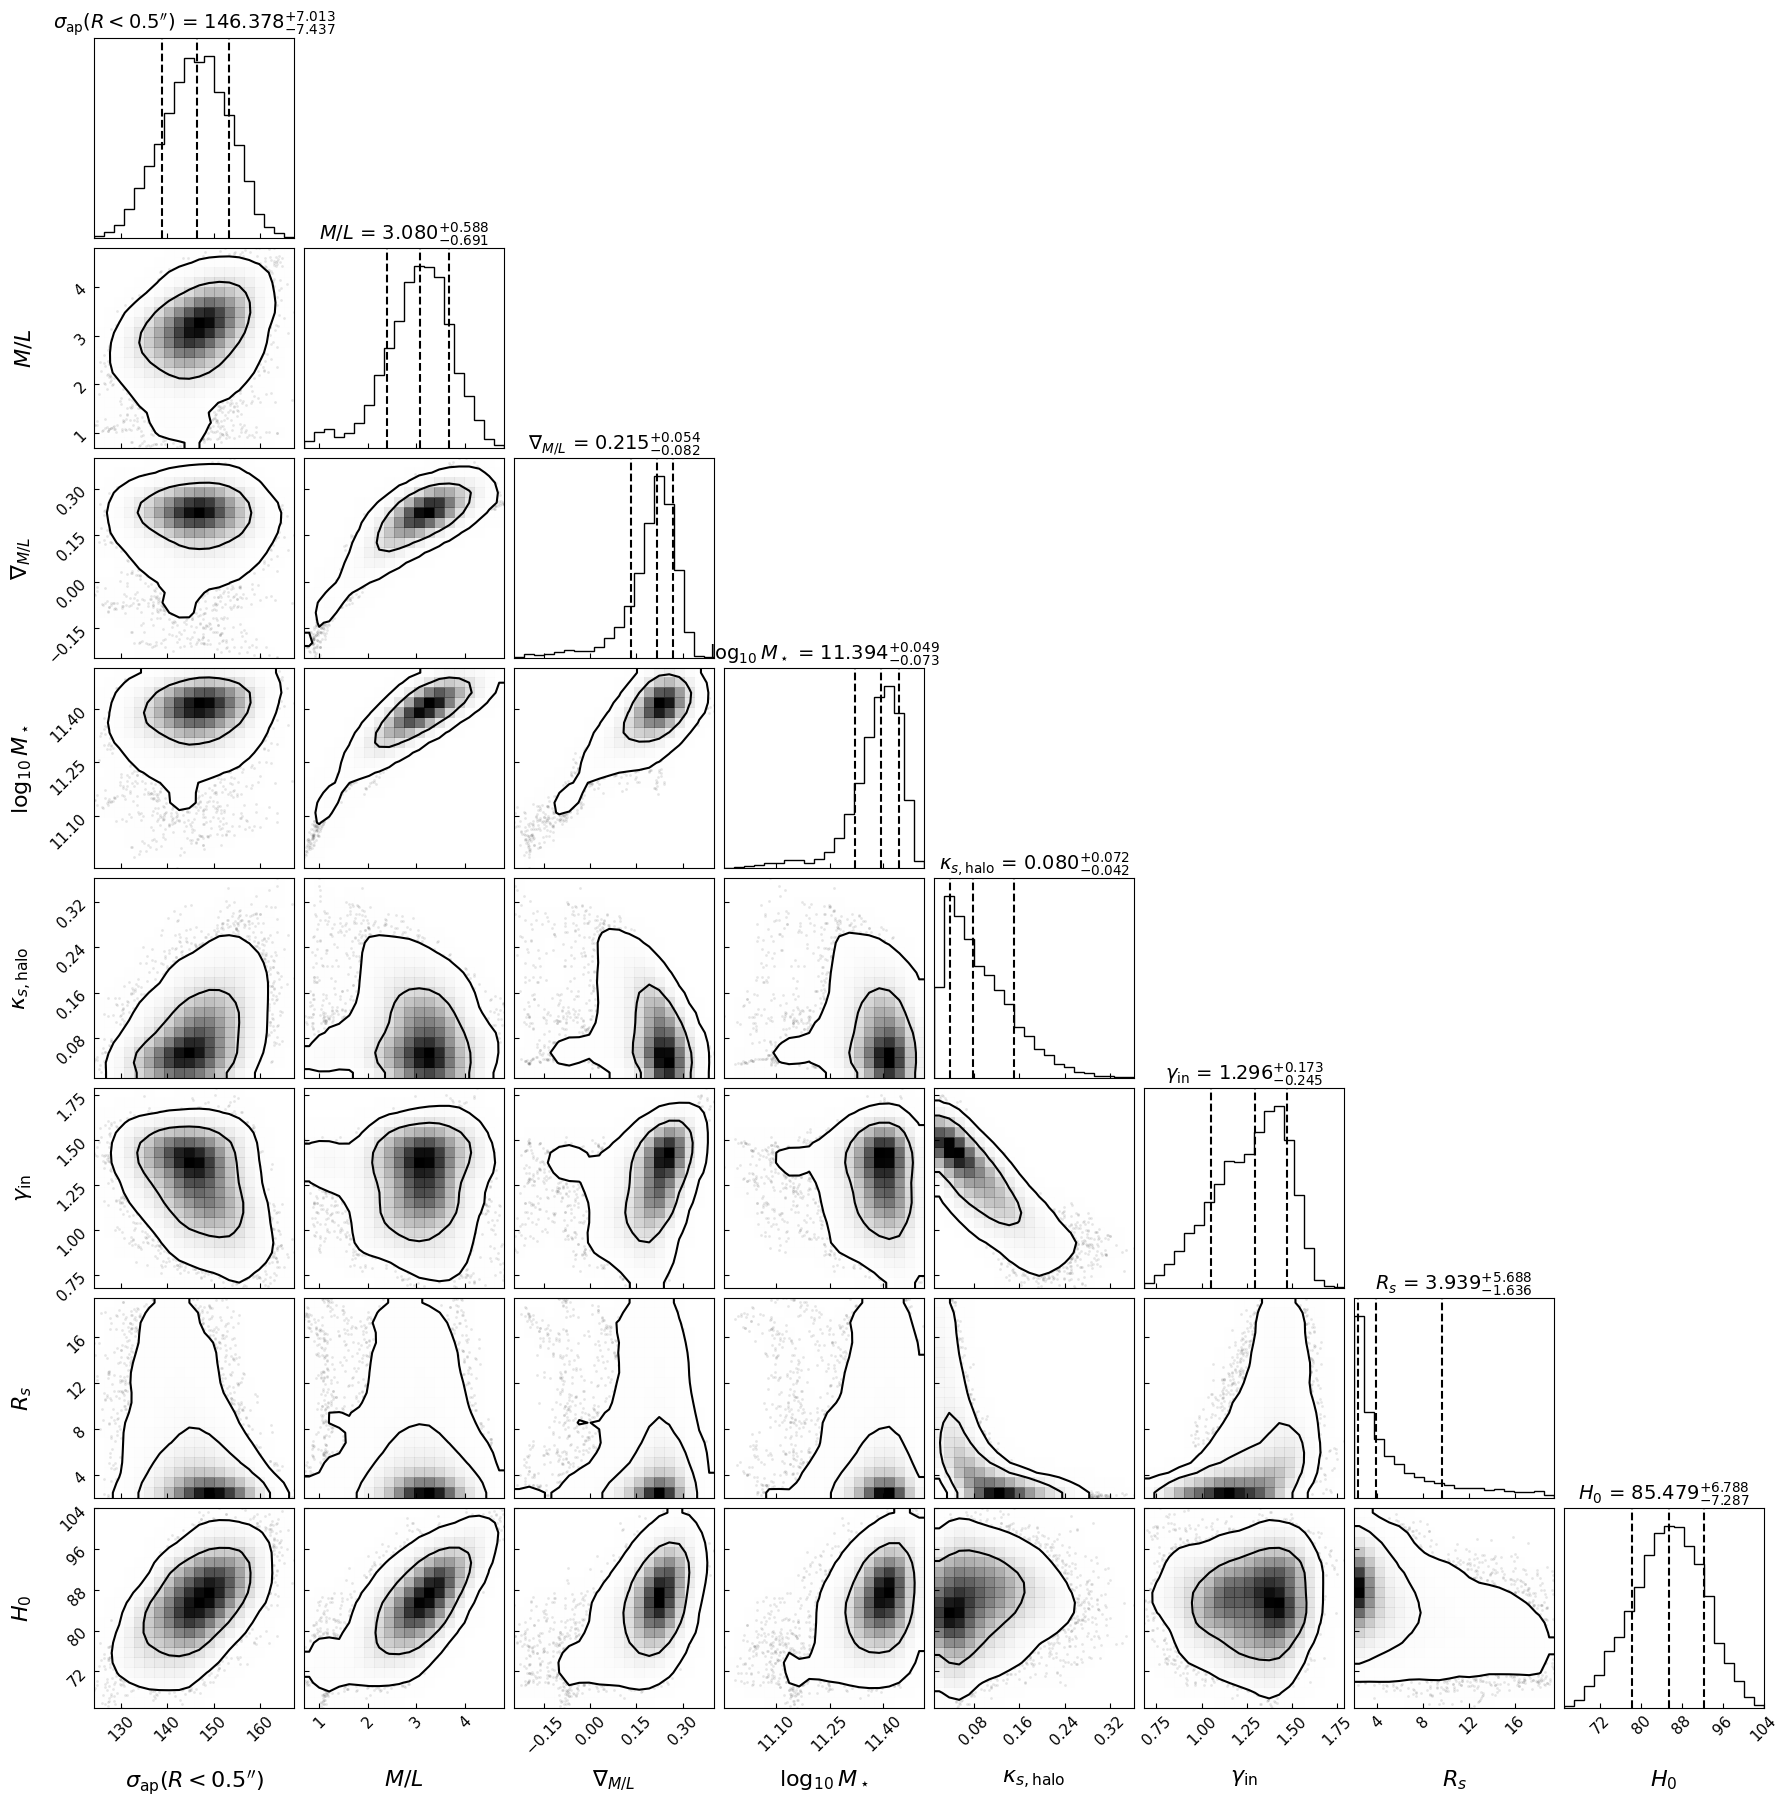

In [10]:
# ============================================================
# Corner plot
# ============================================================
corner_vars = [
    'sigma_ap_0p5_arcsec_km_s',
    'm2l_ratio',
    'm2l_ratio_slope',
    'log10_total_stellar_mass',
    'kappa_s_halo',
    'gammain_halo',
    'Rs_halo',
    'H0_cosmo',
]
labels = [
    r'$\sigma_{\rm ap}(R<0.5^{\prime\prime})$',
    r'$M/L$',
    r'$\nabla_{M/L}$',
    r'$\log_{10} M_\star$',
    r'$\kappa_{s,\rm halo}$',
    r'$\gamma_{\rm in}$',
    r'$R_s$',
    r'$H_0$',
]

fig = corner.corner(
    jam_df[corner_vars],
    labels=labels,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_fmt='.3f',
    smooth=1.0,
    levels=[0.68, 0.95],
    label_kwargs={'fontsize': 16},
    title_kwargs={'fontsize': 14},
)
for ax in fig.get_axes():
    ax.tick_params(axis='both', which='major', labelsize=11, direction='in')

fig.savefig(CORNER_OUT, dpi=300, bbox_inches='tight')
print('saved corner plot to', CORNER_OUT)
plt.show()
